In [44]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, recall_score
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

# =========================================================================
# 1. 데이터 로드 및 기본 구조 확인
# =========================================================================
print("=== 데이터 로드 및 기본 구조 확인 ===")
ccfd_df = pd.read_csv("../creditcard.csv", encoding='latin-1')


=== 데이터 로드 및 기본 구조 확인 ===


In [45]:
ccfd_df.info(

)

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [46]:
ccfd_df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [47]:
ccfd_df.nunique()

Time      124592
V1        275663
V2        275663
V3        275663
V4        275663
V5        275663
V6        275663
V7        275663
V8        275663
V9        275663
V10       275663
V11       275663
V12       275663
V13       275663
V14       275663
V15       275663
V16       275663
V17       275663
V18       275663
V19       275663
V20       275663
V21       275663
V22       275663
V23       275663
V24       275663
V25       275663
V26       275663
V27       275663
V28       275663
Amount     32767
Class          2
dtype: int64

Class
0    284315
1       492
Name: count, dtype: int64

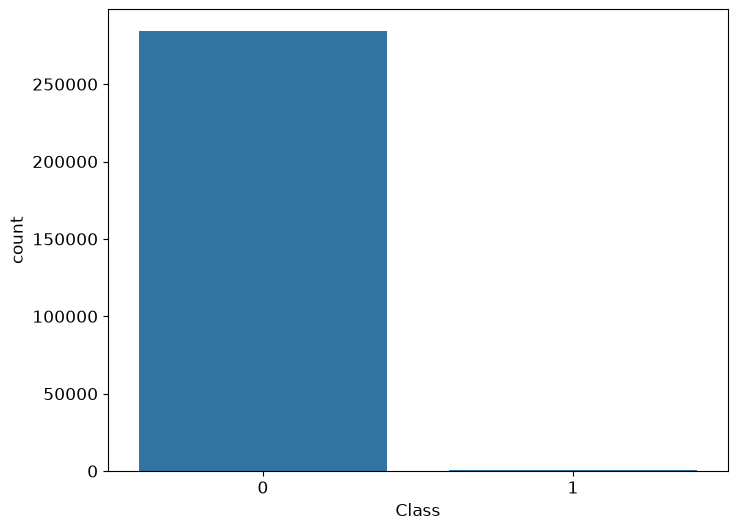

In [48]:
##사기 데이터와 아닌 데이터 0과 1로 구분 
## 범죄 데이터다 보니 당연히 데이터 불균형 발생 
## 284315 정상 결제 492건만 범죄로 보는 케이스 
sns.countplot(x=ccfd_df['Class'])
ccfd_df["Class"].value_counts()

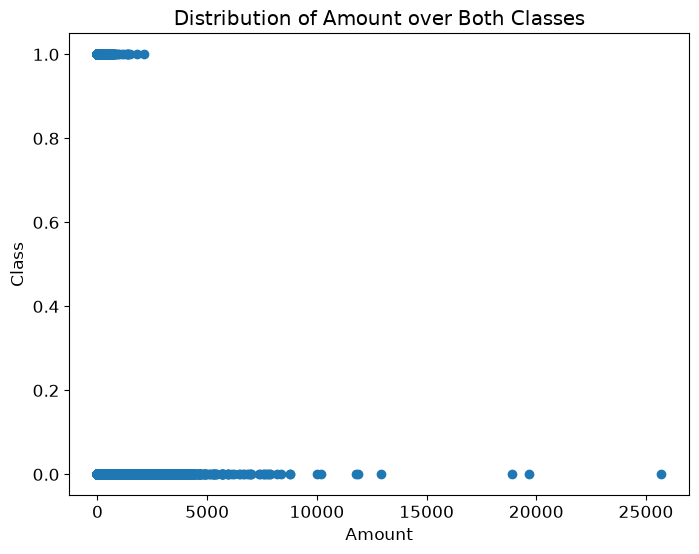

In [49]:
# Adjusting figuresize, and fontsize
plt.rcParams["figure.figsize"] = "8,6"
font = {'size': 12}
plt.rc('font', **font)

# Adding titles to the plots and axes
plt.title("Distribution of Amount over Both Classes")
plt.xlabel("Amount")
plt.ylabel("Class")

# Plotting the Amount column vs. Class Column
plt.scatter(ccfd_df["Amount"],ccfd_df["Class"])

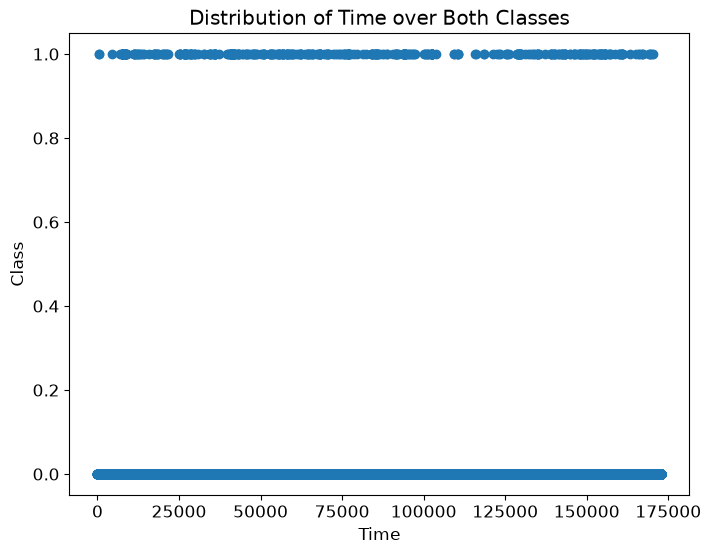

In [50]:
# Adjusting figuresize, and fontsize
plt.rcParams["figure.figsize"] = "8,6"
font = {'size': 12}
plt.rc('font', **font)

# Adding titles to the plots and axes
plt.title("Distribution of Time over Both Classes")
plt.xlabel("Time")
plt.ylabel("Class")

# Plotting the Time column vs. Class Column
plt.scatter(ccfd_df["Time"],ccfd_df["Class"])

<Axes: >

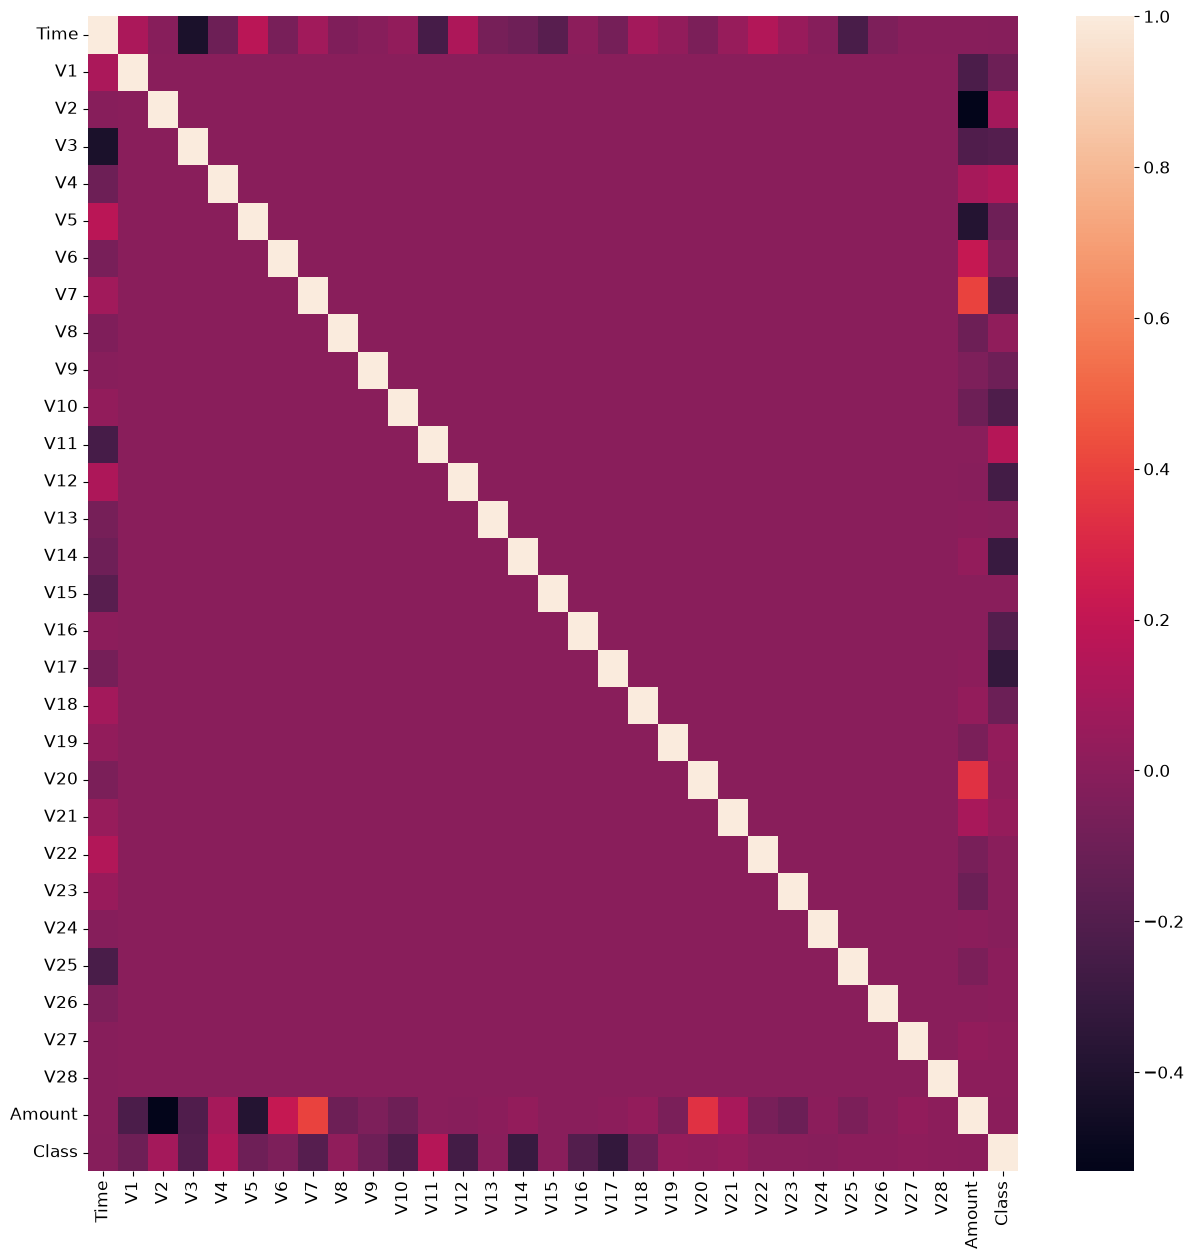

In [51]:
correlation = ccfd_df.corr()
fig = plt.subplots(figsize=(15,15)) 
sns.heatmap(correlation, vmax= 1 )

In [ ]:
# 피처 및 종속 변수(Class) 분리
X = df.drop('Class', axis=1)
y = df['Class']

# 2. 데이터 분할 (학습 데이터 70%, 테스트 데이터 30% / 동일 조건 비교를 위해 random_state 고정)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 3. 피처 스케일링 (Amount 변수 등의 단위 차이 해결용)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# 평가지표 통합 출력 함수
def print_metrics(y_true, y_pred, y_pred_proba, title):
    cm = confusion_matrix(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    prc = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_pred_proba)
    
    print(f"\n=========================================")
    print(f" 📊 {title}")
    print(f"=========================================")
    print("오차 행렬 (Confusion Matrix):")
    print(cm)
    print(f"정확도(Accuracy)  : {acc:.4f}")
    print(f"정밀도(Precision) : {prc:.4f}")
    print(f"재현율(Recall) 🎯  : {rec:.4f}")
    print(f"F1-Score          : {f1:.4f}")
    print(f"ROC-AUC           : {roc_auc:.4f}")

# ----------------------------------------------------------------
# 단계 1: [전처리 전 결과] 스케일링 안 함 + 데이터 불균형 상태 학습
# ----------------------------------------------------------------
model_raw = LogisticRegression(max_iter=1000, random_state=42)
model_raw.fit(X_train_raw, y_train)

y_pred_1 = model_raw.predict(X_test_raw)
y_prob_1 = model_raw.predict_proba(X_test_raw)[:, 1]

print_metrics(y_test, y_pred_1, y_prob_1, "1. 전처리 전 결과 (Raw Data)")


# ----------------------------------------------------------------
# 단계 2: [SMOTE 전 결과] 스케일링 완료 + 데이터 불균형 상태 학습
# ----------------------------------------------------------------
model_scaled = LogisticRegression(max_iter=1000, random_state=42)
model_scaled.fit(X_train_scaled, y_train)

y_pred_2 = model_scaled.predict(X_test_scaled)
y_prob_2 = model_scaled.predict_proba(X_test_scaled)[:, 1]

print_metrics(y_test, y_pred_2, y_prob_2, "2. 전처리 후 + SMOTE 전 결과 (Standard Scaled)")


# ----------------------------------------------------------------
# 단계 3: [SMOTE 후 결과] 스케일링 완료 + Borderline-SMOTE 균형 학습
# ----------------------------------------------------------------
# 재현율 극대화를 위해 class_weight='balanced' 옵션 적용 가능
smote = BorderlineSMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

model_smote = LogisticRegression(max_iter=1000, random_state=42)
model_smote.fit(X_train_balanced, y_train_balanced)

y_pred_3 = model_smote.predict(X_test_scaled)
y_prob_3 = model_smote.predict_proba(X_test_scaled)[:, 1]

print_metrics(y_test, y_pred_3, y_prob_3, "3. 전처리 후 + SMOTE 후 결과 (Scaled + Borderline-SMOTE)")


=== [전처리 전] 로지스틱 회귀 성능 ===
오차 행렬:
[[85279    16]
 [   57    91]]
정확도: 0.9991, 정밀도: 0.8505, 재현율: 0.6149, F1: 0.7137, ROC-AUC: 0.9567, PR-AUC: 0.7072

=== [Borderline-SMOTE 전처리 후] 로지스틱 회귀 성능 ===
오차 행렬:
[[84723   572]
 [   25   123]]
정확도: 0.9930, 정밀도: 0.1770, 재현율: 0.8311, F1: 0.2918, ROC-AUC: 0.9380, PR-AUC: 0.7003
